In [1]:
import subprocess
import sys
from pathlib import Path

requirements_file = Path("requirements.txt")
with requirements_file.open("w", encoding="utf-8") as output:
    subprocess.run([sys.executable, "-m", "pip", "freeze"], stdout=output, check=True)

print(f"Dependencias congeladas en: {requirements_file.resolve()}")

Dependencias congeladas en: C:\Users\abelv\Documents\cursos\Elementos de IA\labs-elementos-ia\01 clustering\requirements.txt


# K-Means para clustering: ejemplo clásico con Iris

Este notebook usa un dataset clásico y muy citado en clustering: **Iris**, un conjunto pequeño, limpio y famoso en la literatura de machine learning. La versión pública del UCI Machine Learning Repository describe 150 observaciones, 4 variables y 3 clases de iris, y lo presenta como un ejemplo clásico para evaluación de métodos de análisis de datos.

También existen otros ejemplos famosos de datasets para clustering disponibles en bibliotecas y repositorios online, como los datasets de ejemplo de seaborn. Aquí nos concentramos en Iris porque es estándar, reproducible y suficiente para ilustrar K-Means, la selección de $k$ y la evaluación de clustering.

Referencias web consultadas:
- UCI Iris: https://archive.ics.uci.edu/dataset/53/iris
- Ejemplos de seaborn: https://seaborn.pydata.org/generated/seaborn.load_dataset.html

In [3]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

SEMILLA = 42
RANGO_K = range(2, 11)


def evaluar_clustering(X_data, etiquetas):
    return {
        'silhouette': silhouette_score(X_data, etiquetas),
        'calinski_harabasz': calinski_harabasz_score(X_data, etiquetas),
        'davies_bouldin': davies_bouldin_score(X_data, etiquetas),
    }


def resumir_clusters(df_original, etiquetas):
    resumen = df_original.copy()
    resumen['cluster'] = etiquetas
    return resumen.groupby('cluster').mean(numeric_only=True).round(2)


def graficar_resultados_2d(df_2d, etiquetas, x_col, y_col, titulo):
    df_plot = df_2d[[x_col, y_col]].copy()
    df_plot['cluster'] = etiquetas
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_plot, x=x_col, y=y_col, hue='cluster', palette='tab10', s=60, alpha=0.8)
    plt.title(titulo)
    plt.tight_layout()

## 1. Carga y comprensión del dataset

Usamos el dataset Iris como ejemplo clásico de clustering. Aunque tiene etiquetas reales, aquí las tratamos solo como referencia para evaluar si K-Means recupera grupos con estructura natural.

In [4]:
iris = load_iris(as_frame=True)
X = iris.data.copy()
y = iris.target.copy()

libros = pd.DataFrame({
    'dataset': ['Iris'],
    'fuente': ['UCI / sklearn'],
    'observaciones': [X.shape[0]],
    'variables': [X.shape[1]],
    'clases_reales': [len(np.unique(y))],
})

display(libros)
display(X.head())
print(iris.DESCR.split('\n')[0])

,dataset,fuente,observaciones,variables,clases_reales
0,Iris,UCI / sklearn,150,4,3


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


.. _iris_dataset:


## 2. Preparación de variables

Como K-Means se apoya en distancias, primero estandarizamos las variables numéricas. Para visualizar los resultados no usaremos PCA; en su lugar mostraremos dos variables originales ya estandarizadas.

Variables estandarizadas para K-Means.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


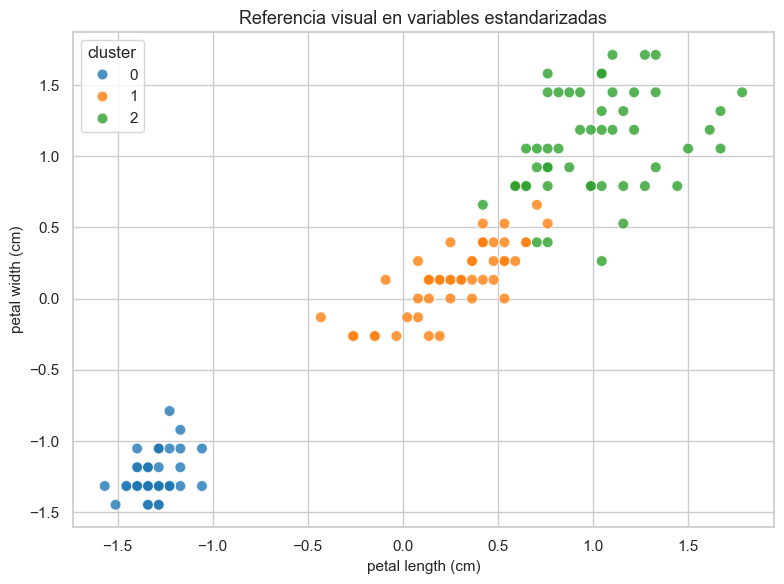

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print('Variables estandarizadas para K-Means.')
display(X_scaled_df.head())

graficar_resultados_2d(X_scaled_df, y, 'petal length (cm)', 'petal width (cm)', 'Referencia visual en variables estandarizadas')

## 3. Selección de k y evaluación de clustering

Usamos varios criterios internos para comparar soluciones: inercia (método del codo), silhouette, Calinski-Harabasz y Davies-Bouldin. Aquí K-Means se ajusta sobre las variables estandarizadas, sin usar PCA.

In [ ]:
k=4
resultados_k = []

modelo = KMeans(n_clusters=k, random_state=SEMILLA, n_init=20)

# modelo.fit(X_scaled)

# etiquetas = modelo.predict(X_scaled)

etiquetas = modelo.fit_predict(X_scaled)

metricas = evaluar_clustering(X_scaled, etiquetas)
resultados_k.append({
    'k': k,
    'inercia': modelo.inertia_,
    **metricas,
})


In [7]:
etiquetas

array([3, 1, 1, 1, 3, 3, 1, 1, 1, 1, 3, 1, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 1, 1, 1, 1, 3, 3, 1, 1, 3, 3, 3, 1, 1, 3, 3, 1, 3, 3, 1, 1, 3,
       3, 1, 3, 1, 3, 1, 2, 2, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 2, 2, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

,k,inercia,silhouette,calinski_harabasz,davies_bouldin
0,2,222.3617,0.5818,251.3493,0.5933
1,3,139.8205,0.4599,241.9044,0.8336
2,4,114.0923,0.3845,207.2664,0.8772
3,5,90.8076,0.3455,203.2674,0.9452
4,6,80.0222,0.3220,187.1401,1.0584
5,7,71.0334,0.3277,177.4803,0.9900
6,8,62.5149,0.3417,174.4106,0.9070
7,9,54.2265,0.3457,177.3905,0.9043
8,10,47.3910,0.3518,181.3875,0.8748


Mejor k sugerido por silhouette/Calinski-Harabasz: 2


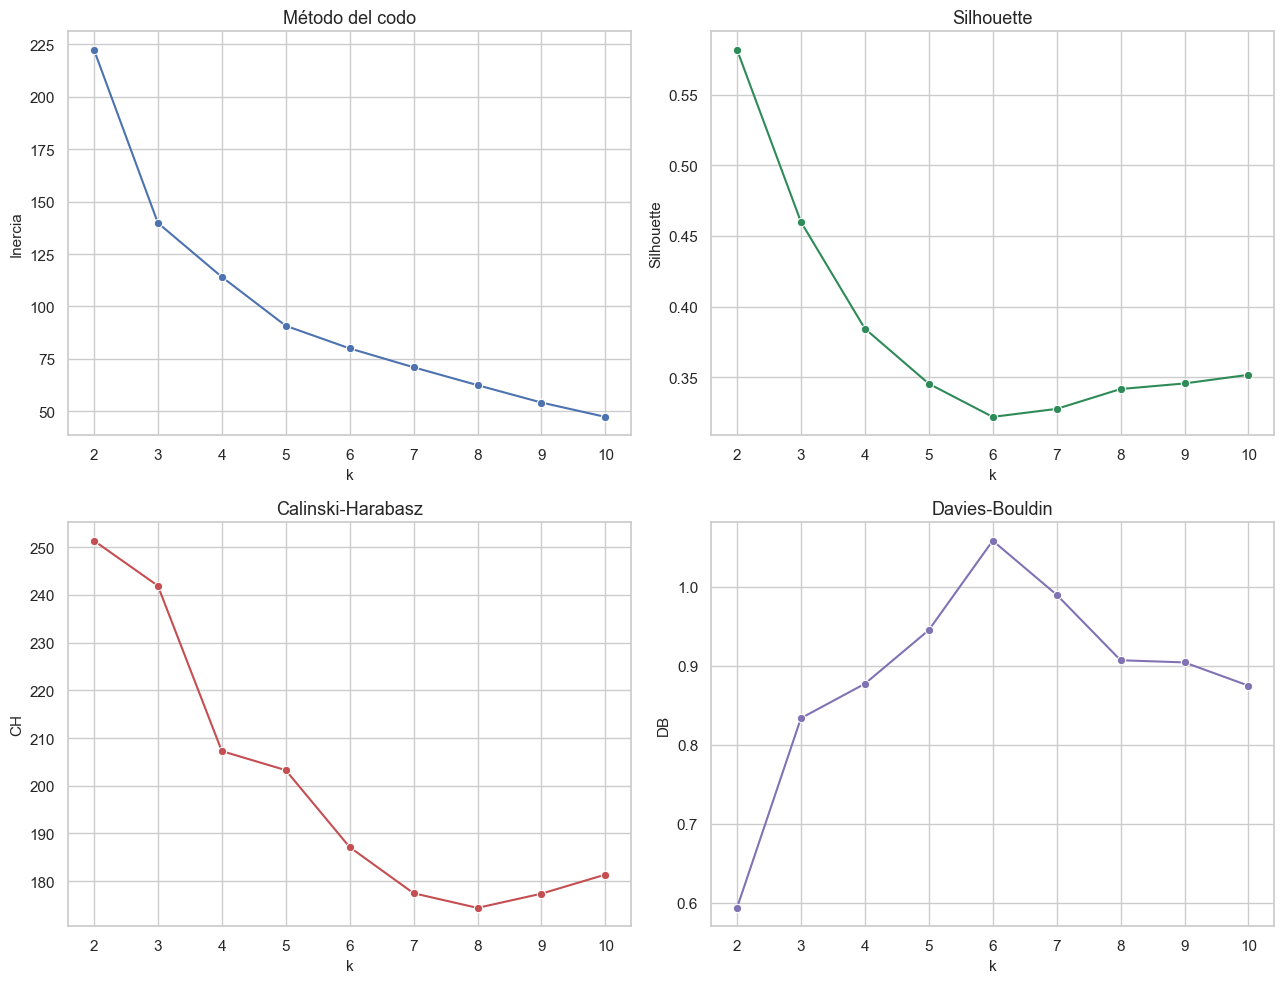

In [8]:
resultados_k = []

for k in RANGO_K:
    modelo = KMeans(n_clusters=k, random_state=SEMILLA, n_init=20)
    etiquetas = modelo.fit_predict(X_scaled)
    metricas = evaluar_clustering(X_scaled, etiquetas)
    resultados_k.append({
        'k': k,
        'inercia': modelo.inertia_,
        **metricas,
    })

resultados_k = pd.DataFrame(resultados_k)
display(resultados_k.round(4))

mejor_k = int(resultados_k.sort_values(['silhouette', 'calinski_harabasz'], ascending=[False, False]).iloc[0]['k'])

print(f'Mejor k sugerido por silhouette/Calinski-Harabasz: {mejor_k}')

mejor_k = 3

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.lineplot(data=resultados_k, x='k', y='inercia', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Método del codo')
axes[0, 0].set_ylabel('Inercia')

sns.lineplot(data=resultados_k, x='k', y='silhouette', marker='o', ax=axes[0, 1], color='#2e8b57')
axes[0, 1].set_title('Silhouette')
axes[0, 1].set_ylabel('Silhouette')

sns.lineplot(data=resultados_k, x='k', y='calinski_harabasz', marker='o', ax=axes[1, 0], color='#c44e52')
axes[1, 0].set_title('Calinski-Harabasz')
axes[1, 0].set_ylabel('CH')

sns.lineplot(data=resultados_k, x='k', y='davies_bouldin', marker='o', ax=axes[1, 1], color='#8172b3')
axes[1, 1].set_title('Davies-Bouldin')
axes[1, 1].set_ylabel('DB')

plt.tight_layout()

## 4. Modelo final e interpretación

Con el mejor $k$ estimado, ajustamos el modelo final, resumimos el perfil de cada cluster y lo contrastamos con las clases reales del dataset para ver hasta qué punto la segmentación recupera la estructura conocida. La visualización se hace en dos variables originales estandarizadas, no con PCA.

Perfil promedio por cluster:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
cluster,,,,
0,5.80,2.67,4.37,1.41
1,5.01,3.43,1.46,0.25
2,6.78,3.10,5.51,1.97


Cruce cluster vs clase real:


clase_real,0,1,2
cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


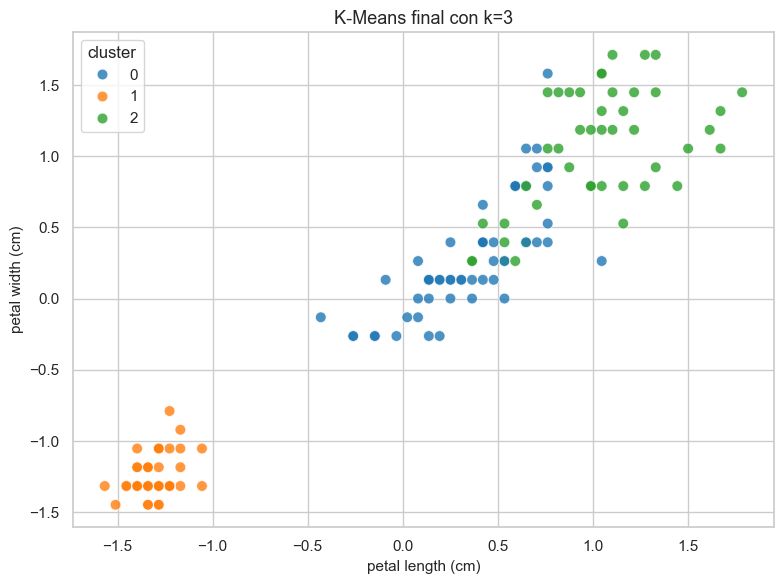

In [9]:
modelo_final = KMeans(n_clusters=mejor_k, random_state=SEMILLA, n_init=20)
etiquetas = modelo_final.fit_predict(X_scaled)

perfil_cluster = resumir_clusters(X, etiquetas)
indices_cluster = pd.DataFrame({'cluster': etiquetas, 'clase_real': y})
cruce = pd.crosstab(indices_cluster['cluster'], indices_cluster['clase_real'])

print('Perfil promedio por cluster:')
display(perfil_cluster)
print('Cruce cluster vs clase real:')
display(cruce)

graficar_resultados_2d(X_scaled_df, etiquetas, 'petal length (cm)', 'petal width (cm)', f'K-Means final con k={mejor_k}')

## 5. Conclusiones

- Iris es un ejemplo clásico y pequeño, ideal para mostrar K-Means con variables estandarizadas.
- En clustering conviene no depender de una sola métrica: silhouette, Calinski-Harabasz, Davies-Bouldin e inercia dan perspectivas distintas.
- En datos con estructura conocida, el cruce con la clase real ayuda a interpretar qué tan bien el algoritmo recupera grupos naturales.
- Si se desea seguir explorando, una extensión natural es comparar K-Means contra clustering jerárquico y GMM en el mismo dataset.
- En este ejemplo no se usa PCA: la visualización se hace con variables originales estandarizadas.

## 6. Old Faithful Geyser: segundo ejemplo clásico de clustering

El dataset Old Faithful registra la duración de las erupciones y el tiempo de espera hasta la siguiente erupción del géiser en Yellowstone. Es un ejemplo clásico en la literatura de clustering y aparece en la documentación de R como un conjunto de 272 observaciones y 2 variables: `eruptions` y `waiting`.

Fuente web consultada:
- R documentation: https://stat.ethz.ch/R-manual/R-devel/library/datasets/html/faithful.html
- CSV público de Rdatasets: https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv

,dataset,fuente,observaciones,variables
0,Old Faithful,R datasets / Rdatasets,272,2


,eruptions,waiting
0,3.600,79
1,1.800,54
2,3.333,74
3,2.283,62
4,4.533,85


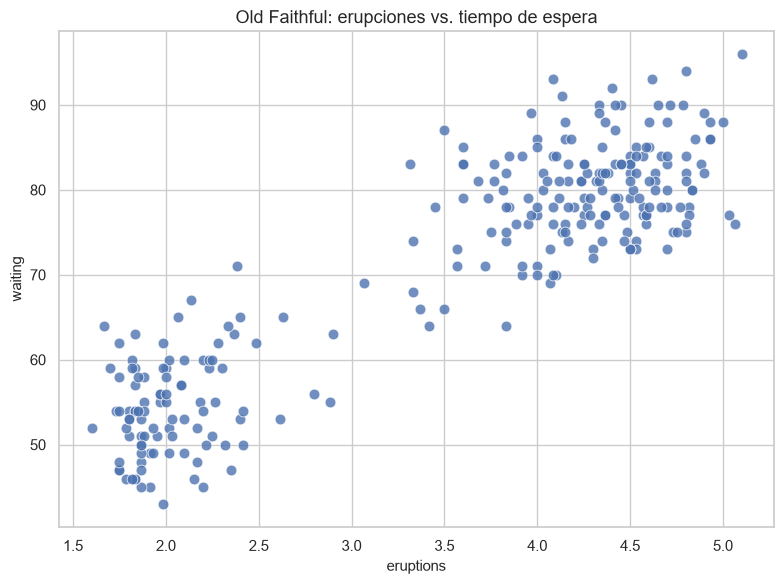

In [26]:
geyser = pd.read_csv('https://vincentarelbundock.github.io/Rdatasets/csv/datasets/faithful.csv')
geyser = geyser.drop(columns=['rownames'])
geyser_numerico = geyser[['eruptions', 'waiting']].copy()

conteo_geyser = pd.DataFrame({
    'dataset': ['Old Faithful'],
    'fuente': ['R datasets / Rdatasets'],
    'observaciones': [geyser.shape[0]],
    'variables': [geyser_numerico.shape[1]],
})

display(conteo_geyser)
display(geyser.head())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=geyser, x='eruptions', y='waiting', ax=ax, s=60, alpha=0.8, color='#4c72b0')
ax.set_title('Old Faithful: erupciones vs. tiempo de espera')
plt.tight_layout()

### Preparación, estandarización y selección de k

Como en el ejemplo de Iris, estandarizamos las variables antes de aplicar K-Means y luego comparamos varios valores de $k$ con métricas internas.

Variables estandarizadas para Old Faithful.


,eruptions,waiting
0,0.098499,0.597123
1,-1.481459,-1.245181
2,-0.135861,0.228663
3,-1.057503,-0.655644
4,0.917443,1.039277


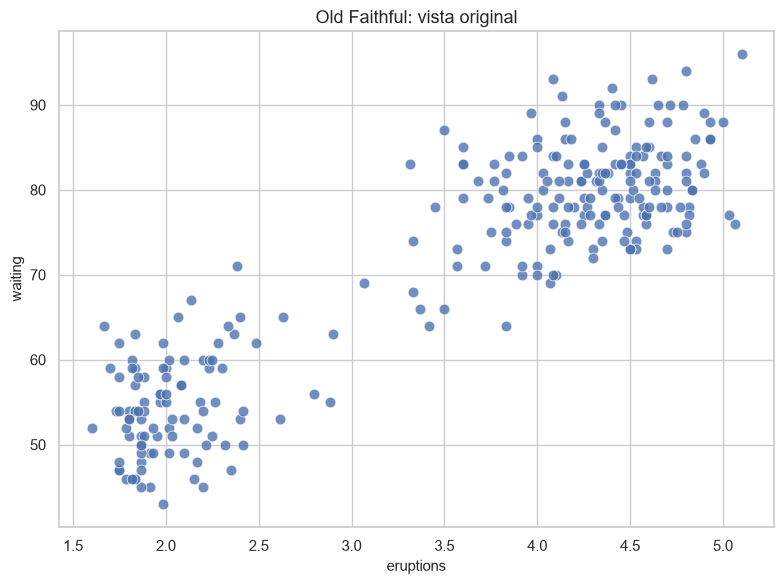

In [27]:
scaler_geyser = StandardScaler()
X_geyser = scaler_geyser.fit_transform(geyser_numerico)
X_geyser_df = pd.DataFrame(X_geyser, columns=geyser_numerico.columns)

print('Variables estandarizadas para Old Faithful.')
display(X_geyser_df.head())

plt.figure(figsize=(8, 6))
sns.scatterplot(data=geyser_numerico, x='eruptions', y='waiting', s=60, alpha=0.8, color='#4c72b0')
plt.title('Old Faithful: vista original')
plt.tight_layout()

### Lectura de negocio

El patrón de Old Faithful suele separarse en dos comportamientos claros: erupciones cortas con esperas cortas y erupciones largas con esperas largas. K-Means captura esa separación de forma natural cuando $k=2$, lo que lo convierte en un ejemplo muy útil para explicar segmentación no supervisada en dos variables.

,k,inercia,silhouette,calinski_harabasz,davies_bouldin
0,2,79.5760,0.7452,1575.7836,0.3406
1,3,56.3136,0.4851,1164.7950,0.8180
2,4,43.8710,0.3815,1018.4002,0.9342
3,5,34.2744,0.3628,992.7003,0.9362
4,6,27.2843,0.3920,1007.5141,0.8465
5,7,23.8372,0.3902,963.7827,0.8379
6,8,20.8083,0.3611,948.2647,0.8710
7,9,18.5641,0.3599,930.4914,0.8669
8,10,16.9265,0.3656,906.4878,0.8473


Mejor k sugerido para Old Faithful: 2
Perfil promedio por cluster en Old Faithful:


,eruptions,waiting
cluster,,
0,4.30,80.08
1,2.05,54.59


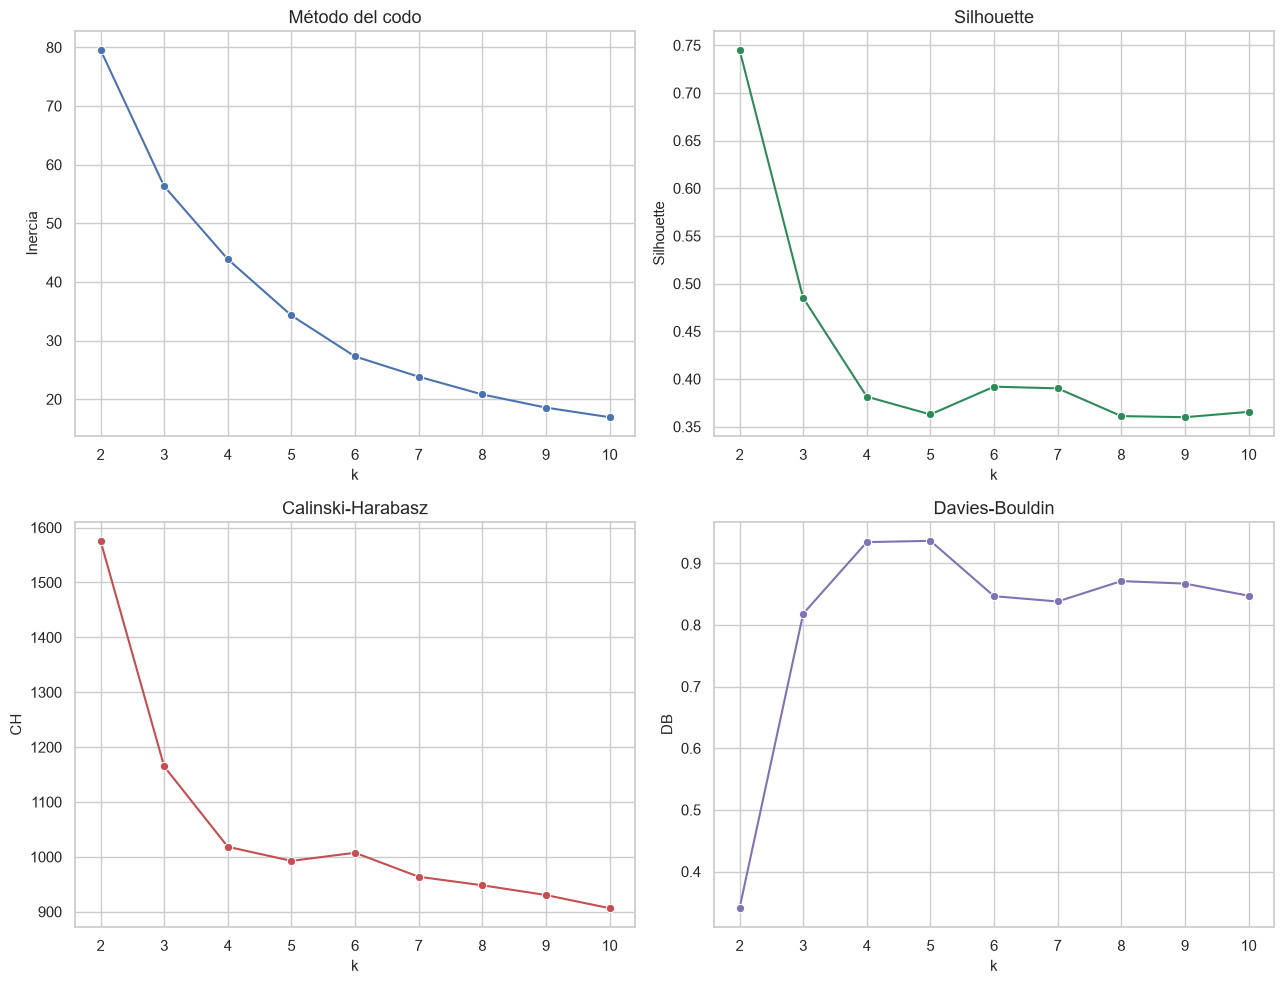

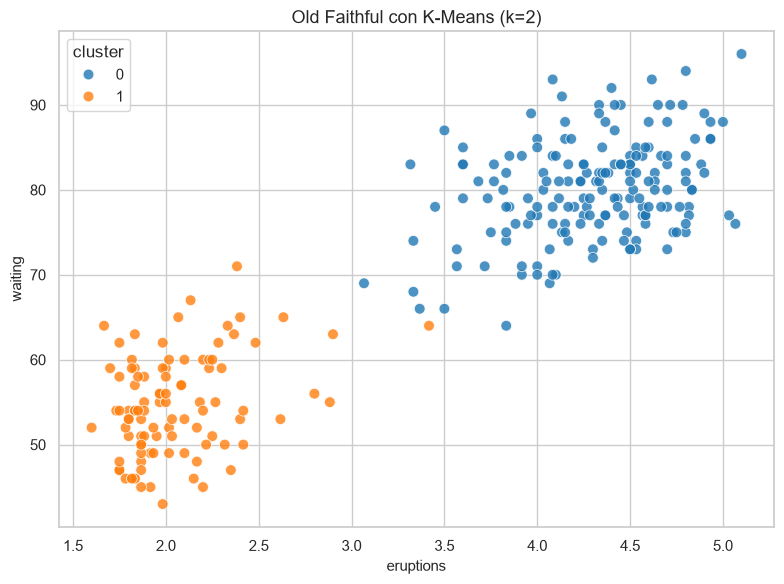

In [28]:
resultados_k_geyser = []

for k in RANGO_K:
    modelo_geyser = KMeans(n_clusters=k, random_state=SEMILLA, n_init=20)
    etiquetas_geyser = modelo_geyser.fit_predict(X_geyser)
    metricas = evaluar_clustering(X_geyser, etiquetas_geyser)
    resultados_k_geyser.append({
        'k': k,
        'inercia': modelo_geyser.inertia_,
        **metricas,
    })

resultados_k_geyser = pd.DataFrame(resultados_k_geyser)
display(resultados_k_geyser.round(4))

mejor_k_geyser = int(resultados_k_geyser.sort_values(['silhouette', 'calinski_harabasz'], ascending=[False, False]).iloc[0]['k'])
print(f'Mejor k sugerido para Old Faithful: {mejor_k_geyser}')

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.lineplot(data=resultados_k_geyser, x='k', y='inercia', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Método del codo')
axes[0, 0].set_ylabel('Inercia')

sns.lineplot(data=resultados_k_geyser, x='k', y='silhouette', marker='o', ax=axes[0, 1], color='#2e8b57')
axes[0, 1].set_title('Silhouette')
axes[0, 1].set_ylabel('Silhouette')

sns.lineplot(data=resultados_k_geyser, x='k', y='calinski_harabasz', marker='o', ax=axes[1, 0], color='#c44e52')
axes[1, 0].set_title('Calinski-Harabasz')
axes[1, 0].set_ylabel('CH')

sns.lineplot(data=resultados_k_geyser, x='k', y='davies_bouldin', marker='o', ax=axes[1, 1], color='#8172b3')
axes[1, 1].set_title('Davies-Bouldin')
axes[1, 1].set_ylabel('DB')

plt.tight_layout()

modelo_geyser = KMeans(n_clusters=mejor_k_geyser, random_state=SEMILLA, n_init=20)
etiquetas_geyser = modelo_geyser.fit_predict(X_geyser)
perfil_geyser = resumir_clusters(geyser_numerico, etiquetas_geyser)

print('Perfil promedio por cluster en Old Faithful:')
display(perfil_geyser)

graficar_resultados_2d(geyser_numerico, etiquetas_geyser, 'eruptions', 'waiting', f'Old Faithful con K-Means (k={mejor_k_geyser})')

### Conclusiones de Old Faithful

K-Means encuentra de forma natural dos grupos bien separados cuando $k=2$, lo que coincide con la intuición visual del conjunto: erupciones cortas con esperas cortas y erupciones largas con esperas largas. Esto convierte a Old Faithful en un ejemplo muy claro para explicar por qué la estandarización previa es importante y por qué la elección de $k$ debe apoyarse en varias métricas, no solo en la inercia.

## 7. Wholesale Customers: tercer ejemplo clásico de clustering

Wholesale Customers es un dataset clásico de UCI sobre clientes de un distribuidor mayorista. Incluye el gasto anual en seis categorías de productos y es muy útil para ilustrar segmentación de clientes con K-Means.

Fuente web consultada:
- UCI: https://archive.ics.uci.edu/dataset/292/wholesale+customers

,dataset,fuente,observaciones,variables_modelo,variables_totales
0,Wholesale Customers,UCI,440,6,7


,Channel,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,12669,9656,7561,214,2674,1338
1,2,7057,9810,9568,1762,3293,1776
2,2,6353,8808,7684,2405,3516,7844
3,1,13265,1196,4221,6404,507,1788
4,2,22615,5410,7198,3915,1777,5185


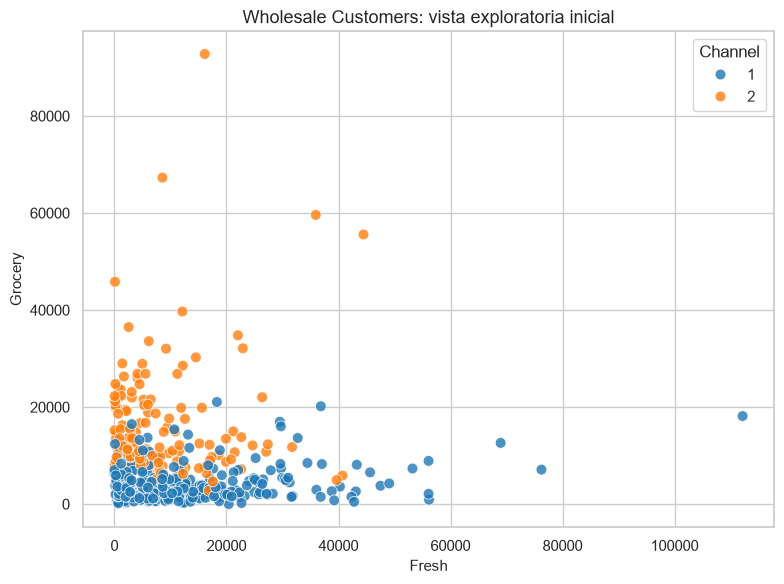

In [29]:
from ucimlrepo import fetch_ucirepo

wholesale = fetch_ucirepo(id=292)
wholesale_X = wholesale.data.features.copy()
wholesale_y = wholesale.data.targets.copy()

columnas_modelo = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']
wholesale_numerico = wholesale_X[columnas_modelo].copy()

conteo_wholesale = pd.DataFrame({
    'dataset': ['Wholesale Customers'],
    'fuente': ['UCI'],
    'observaciones': [wholesale_X.shape[0]],
    'variables_modelo': [wholesale_numerico.shape[1]],
    'variables_totales': [wholesale_X.shape[1]],
})

display(conteo_wholesale)
display(wholesale_X.head())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=wholesale_X, x='Fresh', y='Grocery', hue='Channel', palette='tab10', s=60, alpha=0.8, ax=ax)
ax.set_title('Wholesale Customers: vista exploratoria inicial')
plt.tight_layout()

### Preparación y evaluación para Wholesale Customers

Para este conjunto usamos una transformación logarítmica suave sobre las variables de gasto y después estandarizamos. Esto reduce la asimetría de los montos y hace que K-Means trabaje con distancias más equilibradas.

Variables de gasto transformadas con log1p y estandarizadas.


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.486184,0.976299,0.440155,-1.509250,0.644143,0.408966
1,0.087889,0.990956,0.652171,0.134052,0.766043,0.627926
2,0.016356,0.891151,0.454687,0.376899,0.804405,1.776833
3,0.517477,-0.957973,-0.084792,1.141574,-0.328712,0.633133
4,0.880631,0.439662,0.395847,0.757322,0.404939,1.456588


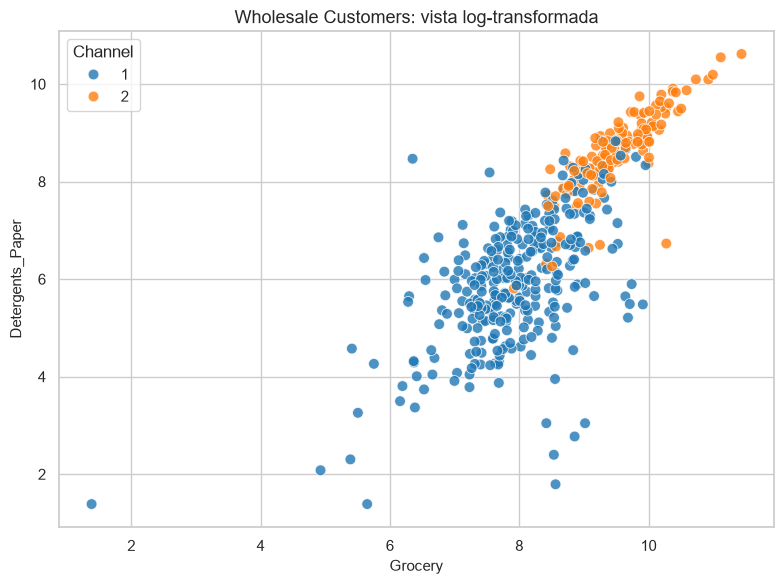

In [10]:
wholesale_log = np.log1p(wholesale_numerico)
scaler_wholesale = StandardScaler()
X_wholesale = scaler_wholesale.fit_transform(wholesale_log)
X_wholesale_df = pd.DataFrame(X_wholesale, columns=columnas_modelo)

print('Variables de gasto transformadas con log1p y estandarizadas.')
display(X_wholesale_df.head())

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=wholesale_log, x='Grocery', y='Detergents_Paper', hue=wholesale_X['Channel'], palette='tab10', s=60, alpha=0.8, ax=ax)
ax.set_title('Wholesale Customers: vista log-transformada')
plt.tight_layout()

### Selección de k y lectura de negocio

Buscamos el mejor $k$ con varias métricas internas y luego analizamos la composición de los clusters respecto a `Channel` y `Region`.

In [12]:
resultados_k_wholesale = []

for k in RANGO_K:
    modelo_wholesale = KMeans(n_clusters=k, random_state=SEMILLA, n_init=20)
    etiquetas_wholesale = modelo_wholesale.fit_predict(X_wholesale)
    metricas = evaluar_clustering(X_wholesale, etiquetas_wholesale)
    resultados_k_wholesale.append({
        'k': k,
        'inercia': modelo_wholesale.inertia_,
        **metricas,
    })

resultados_k_wholesale = pd.DataFrame(resultados_k_wholesale)
display(resultados_k_wholesale.round(4))

mejor_k_wholesale = int(resultados_k_wholesale.sort_values(['silhouette', 'calinski_harabasz'], ascending=[False, False]).iloc[0]['k'])
print(f'Mejor k sugerido para Wholesale Customers: {mejor_k_wholesale}')

,k,inercia,silhouette,calinski_harabasz,davies_bouldin
0,2,1844.0641,0.2903,189.0498,1.3515
1,3,1553.4127,0.2583,152.8372,1.3482
2,4,1386.8627,0.1885,131.3199,1.5408
3,5,1266.1494,0.1916,118.0005,1.4843
4,6,1174.5364,0.1953,108.3000,1.4135
5,7,1086.3587,0.1958,103.2082,1.3919
6,8,1024.0468,0.1915,97.3856,1.3855
7,9,973.1415,0.1965,92.2805,1.3825
8,10,931.9985,0.1905,87.5586,1.3437


Mejor k sugerido para Wholesale Customers: 2


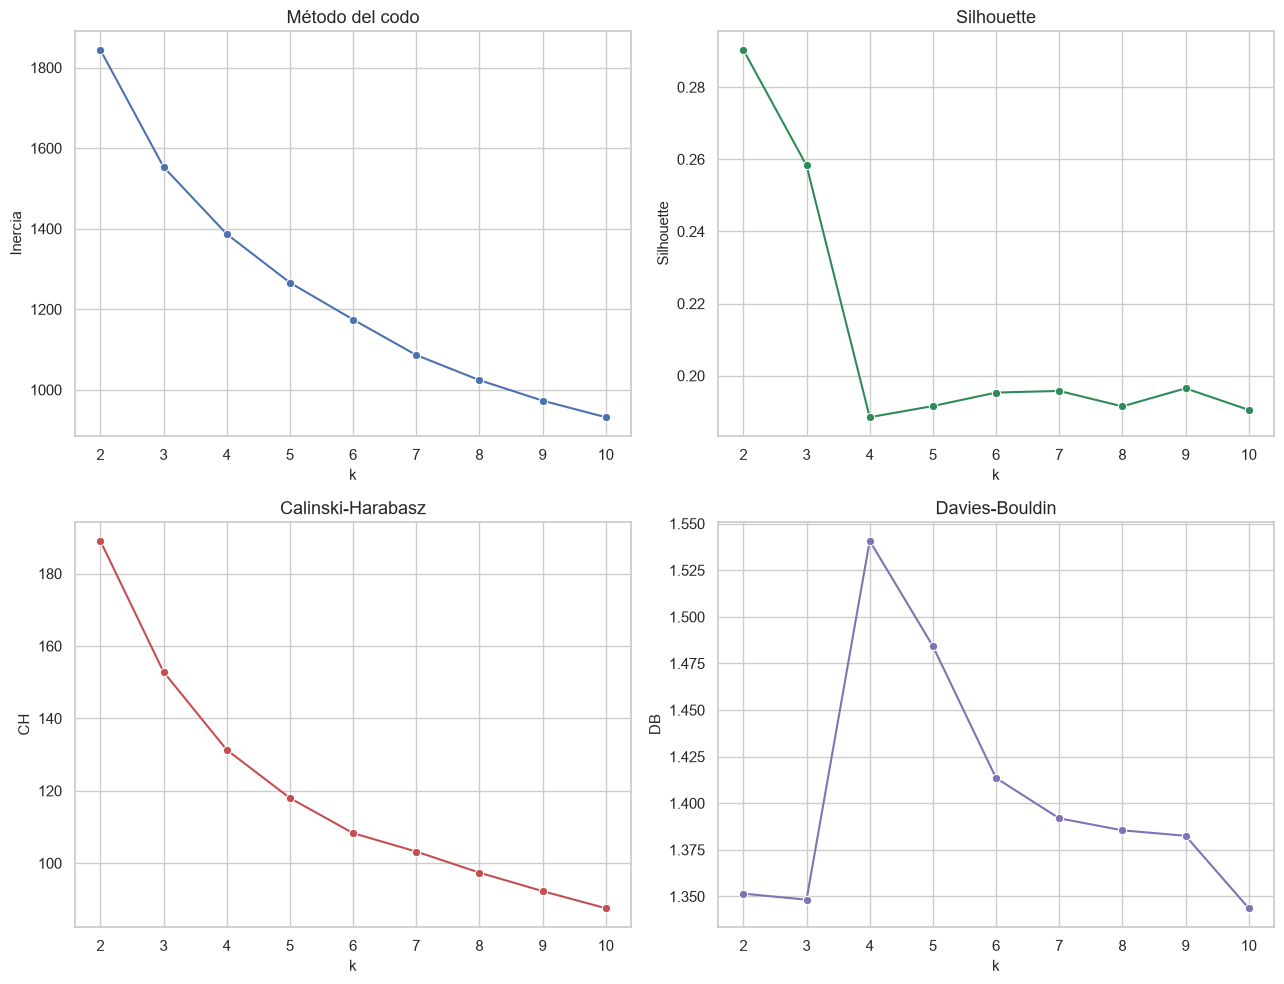

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.lineplot(data=resultados_k_wholesale, x='k', y='inercia', marker='o', ax=axes[0, 0])
axes[0, 0].set_title('Método del codo')
axes[0, 0].set_ylabel('Inercia')

sns.lineplot(data=resultados_k_wholesale, x='k', y='silhouette', marker='o', ax=axes[0, 1], color='#2e8b57')
axes[0, 1].set_title('Silhouette')
axes[0, 1].set_ylabel('Silhouette')

sns.lineplot(data=resultados_k_wholesale, x='k', y='calinski_harabasz', marker='o', ax=axes[1, 0], color='#c44e52')
axes[1, 0].set_title('Calinski-Harabasz')
axes[1, 0].set_ylabel('CH')

sns.lineplot(data=resultados_k_wholesale, x='k', y='davies_bouldin', marker='o', ax=axes[1, 1], color='#8172b3')
axes[1, 1].set_title('Davies-Bouldin')
axes[1, 1].set_ylabel('DB')

plt.tight_layout()

### Comparación de k según diferentes métodos

Ahora comparamos cómo cambia completamente la segmentación según qué métrica usamos para elegir k. Cada método puede sugerir un k distinto, resultando en interpretaciones muy diferentes del mismo dataset.


In [38]:
# Identificar el mejor k según cada método
mejor_k_por_metodo = {}

# 1. Inercia: buscar el "codo" (k con mayor caída relativa)
inercias = resultados_k_wholesale['inercia'].values
cambios_inercia = np.diff(inercias)
cambios_rel = np.abs(cambios_inercia[:-1] - cambios_inercia[1:])
mejor_k_por_metodo['inercia'] = int(resultados_k_wholesale.iloc[np.argmax(cambios_rel) + 1]['k'])

# 2. Silhouette: máximo
mejor_k_por_metodo['silhouette'] = int(resultados_k_wholesale.loc[resultados_k_wholesale['silhouette'].idxmax(), 'k'])

# 3. Calinski-Harabasz: máximo
mejor_k_por_metodo['calinski_harabasz'] = int(resultados_k_wholesale.loc[resultados_k_wholesale['calinski_harabasz'].idxmax(), 'k'])

# 4. Davies-Bouldin: mínimo (mejor cuando es más bajo)
mejor_k_por_metodo['davies_bouldin'] = int(resultados_k_wholesale.loc[resultados_k_wholesale['davies_bouldin'].idxmin(), 'k'])

resumen_metodos = pd.DataFrame([{
    'Método': metodo.replace('_', ' ').title(),
    'k recomendado': k_val
} for metodo, k_val in mejor_k_por_metodo.items()])

print('K recomendado según cada método de evaluación:')
display(resumen_metodos)


K recomendado según cada método de evaluación:


,Método,k recomendado
0,Inercia,3
1,Silhouette,2
2,Calinski Harabasz,2
3,Davies Bouldin,10


In [39]:
# Entrenar modelos K-Means para cada k sugerido
modelos_comparativos = {}

for metodo, k_val in mejor_k_por_metodo.items():
    modelo_temp = KMeans(n_clusters=k_val, random_state=SEMILLA, n_init=20)
    etiquetas_temp = modelo_temp.fit_predict(X_wholesale)
    modelos_comparativos[metodo] = {
        'k': k_val,
        'modelo': modelo_temp,
        'etiquetas': etiquetas_temp,
        'metricas': evaluar_clustering(X_wholesale, etiquetas_temp),
        'inercia': modelo_temp.inertia_
    }

print('Modelos entrenados para comparación:')
for metodo, datos in modelos_comparativos.items():
    print(f"  {metodo:20} → k={datos['k']}, silhouette={datos['metricas']['silhouette']:.4f}")


Modelos entrenados para comparación:
  inercia              → k=3, silhouette=0.2583
  silhouette           → k=2, silhouette=0.2903
  calinski_harabasz    → k=2, silhouette=0.2903
  davies_bouldin       → k=10, silhouette=0.1905


In [40]:
# Comparar perfiles de clusters por cada método
print('='*80)
print('PERFILES DE CLUSTERS POR MÉTODO DE SELECCIÓN DE K')
print('='*80)

for metodo, datos in modelos_comparativos.items():
    print(f'\n{"─"*80}')
    print(f'MÉTODO: {metodo.replace("_", " ").upper()} (k={datos["k"]})')
    print(f'{"─"*80}')
    
    # Crear dataframe con etiquetas de clusters
    resultados_temp = wholesale_X.copy()
    resultados_temp['cluster'] = datos['etiquetas']
    resultados_temp['Region'] = wholesale_y['Region']
    
    # Perfil promedio
    perfil_temp = resultados_temp.groupby('cluster')[columnas_modelo].mean().round(2)
    print('\nPerfil promedio de gasto por cluster:')
    display(perfil_temp)
    
    # Composición por Channel
    ct_channel = pd.crosstab(resultados_temp['cluster'], resultados_temp['Channel'], margins=True)
    print('\nDistribución por Channel:')
    display(ct_channel)
    
    # Composición por Region
    ct_region = pd.crosstab(resultados_temp['cluster'], resultados_temp['Region'], margins=True)
    print('\nDistribución por Region:')
    display(ct_region)


PERFILES DE CLUSTERS POR MÉTODO DE SELECCIÓN DE K

────────────────────────────────────────────────────────────────────────────────
MÉTODO: INERCIA (k=3)
────────────────────────────────────────────────────────────────────────────────

Perfil promedio de gasto por cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,17182.39,10658.08,13380.98,4181.11,5003.64,2867.22
1,11992.59,1995.43,2496.92,3277.84,425.91,892.50
2,2966.93,7010.90,12397.28,608.28,5446.23,795.00



Distribución por Channel:


Channel,1,2,All
cluster,,,
0,56,89,145
1,209,3,212
2,33,50,83
All,298,142,440



Distribución por Region:


...

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,9532.56,6930.28,12348.44,1542.44,5231.94,64.11
1,13926.83,1782.13,2416.17,4294.30,408.07,927.73
2,20852.62,31453.69,34439.38,4129.75,16187.19,4306.38
3,28301.73,7317.51,7181.67,10104.11,994.89,4200.49
4,2649.38,4512.35,3686.85,1786.55,556.02,1549.30
5,8673.68,631.10,777.23,1655.26,289.10,386.94
6,2298.36,9335.64,16844.19,456.12,7775.98,1475.74
7,10054.04,8517.44,12843.25,1716.80,5436.94,1796.62
8,168.73,2212.64,7118.27,1617.27,1829.18,190.27



Distribución por Channel:


Channel,1,2,All
cluster,,,
0,6,12,18
1,112,2,114
2,1,15,16
3,41,4,45
4,39,1,40
5,31,0,31
6,7,35,42
7,8,63,71
8,9,2,11



Distribución por Region:


Region,1,2,3,All
cluster,,,,
0,2,4,12,18
1,21,17,76,114
2,3,1,12,16
3,10,1,34,45
4,8,2,30,40
5,8,1,22,31
6,7,6,29,42
7,9,7,55,71
8,1,2,8,11


Text(0.5, 1.0, 'Comparación de K-Means: Segmentación según método de selección de k')

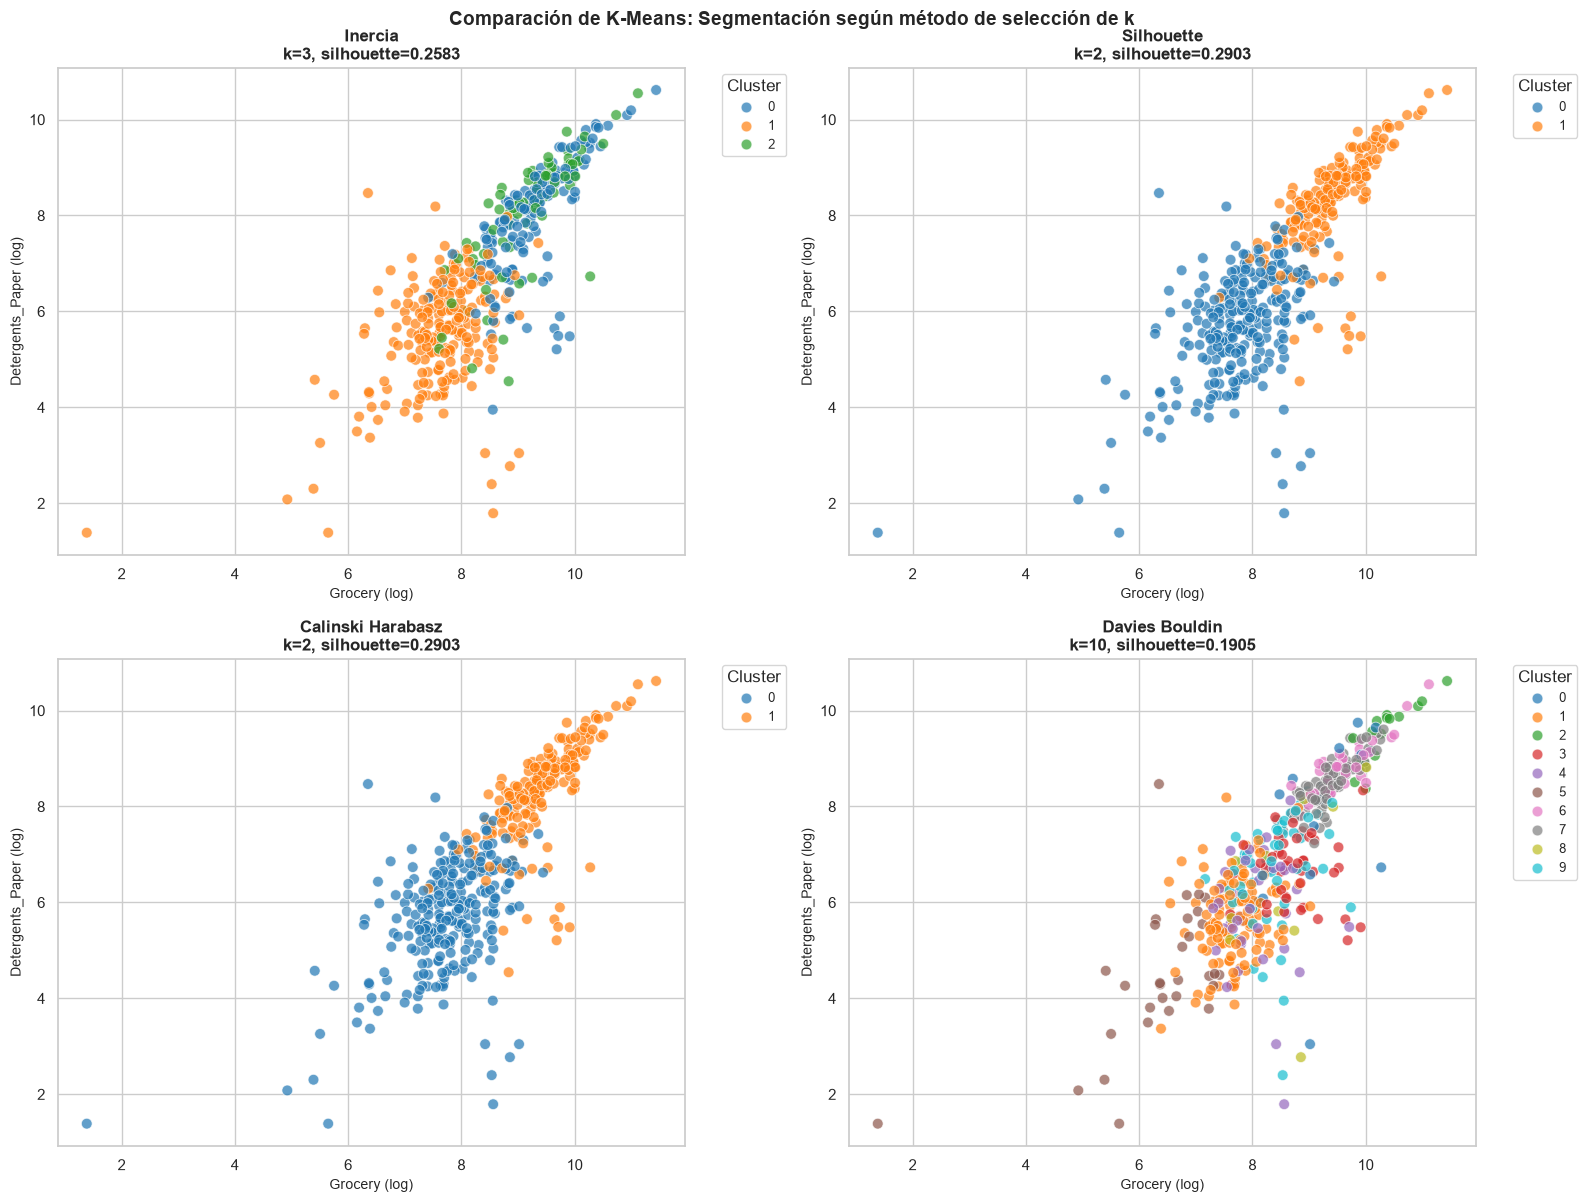

In [41]:
# Visualización comparativa: scatter plots lado a lado
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, (metodo, datos) in enumerate(modelos_comparativos.items()):
    ax = axes[idx]
    
    # Transformar datos a log para visualización
    x_col = 'Grocery'
    y_col = 'Detergents_Paper'
    
    plot_data = pd.DataFrame({
        'Grocery': np.log1p(wholesale_X[x_col]),
        'Detergents_Paper': np.log1p(wholesale_X[y_col]),
        'cluster': datos['etiquetas']
    })
    
    sns.scatterplot(data=plot_data, x='Grocery', y='Detergents_Paper', 
                    hue='cluster', palette='tab10', s=60, alpha=0.7, ax=ax)
    
    ax.set_title(f'{metodo.replace("_", " ").title()}\nk={datos["k"]}, silhouette={datos["metricas"]["silhouette"]:.4f}',
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Grocery (log)', fontsize=10)
    ax.set_ylabel('Detergents_Paper (log)', fontsize=10)
    ax.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.suptitle('Comparación de K-Means: Segmentación según método de selección de k', 
            fontsize=14, fontweight='bold', y=1.00)


In [42]:
# Tabla resumen: comparativa de métricas para cada k elegido por cada método
resumen_comparativo = []

for metodo, datos in modelos_comparativos.items():
    resumen_comparativo.append({
        'Método': metodo.replace('_', ' ').title(),
        'k': datos['k'],
        'Inercia': datos['inercia'],
        'Silhouette': datos['metricas']['silhouette'],
        'Calinski-Harabasz': datos['metricas']['calinski_harabasz'],
        'Davies-Bouldin': datos['metricas']['davies_bouldin'],
    })

df_resumen_comp = pd.DataFrame(resumen_comparativo).round(4)
print('\nRESUMEN COMPARATIVO DE SOLUCIONES:')
print('='*100)
display(df_resumen_comp)

print('\n\nINTERPRETACIÓN:')
print('─'*100)
print(f'• La cantidad de clusters varía de k={min([d["k"] for d in modelos_comparativos.values()])} a k={max([d["k"] for d in modelos_comparativos.values()])}')
print(f'• Cada método optimiza una métrica diferente, resultando en segmentaciones distintas')
print(f'• En la práctica, debe elegirse el k que mejor responda a:')
print(f'    1. La interpretación de negocio (¿cuántos segmentos realmente necesitamos?)')
print(f'    2. La estabilidad de las métricas (¿hay consenso entre métodos?)')
print(f'    3. La cohesión dentro de clusters (silhouette alto) vs separación entre ellos (CH alto)')



RESUMEN COMPARATIVO DE SOLUCIONES:


,Método,k,Inercia,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,Inercia,3,1553.4127,0.2583,152.8372,1.3482
1,Silhouette,2,1844.0641,0.2903,189.0498,1.3515
2,Calinski Harabasz,2,1844.0641,0.2903,189.0498,1.3515
3,Davies Bouldin,10,931.9985,0.1905,87.5586,1.3437




INTERPRETACIÓN:
────────────────────────────────────────────────────────────────────────────────────────────────────
• La cantidad de clusters varía de k=2 a k=10
• Cada método optimiza una métrica diferente, resultando en segmentaciones distintas
• En la práctica, debe elegirse el k que mejor responda a:
    1. La interpretación de negocio (¿cuántos segmentos realmente necesitamos?)
    2. La estabilidad de las métricas (¿hay consenso entre métodos?)
    3. La cohesión dentro de clusters (silhouette alto) vs separación entre ellos (CH alto)


In [43]:
modelo_wholesale = KMeans(n_clusters=mejor_k_wholesale, random_state=SEMILLA, n_init=20)
etiquetas_wholesale = modelo_wholesale.fit_predict(X_wholesale)

wholesale_resultados = wholesale_X.copy()
wholesale_resultados['cluster'] = etiquetas_wholesale
wholesale_resultados['Region'] = wholesale_y['Region']

perfil_wholesale = wholesale_resultados.groupby('cluster')[columnas_modelo].mean().round(2)
cluster_channel = pd.crosstab(wholesale_resultados['cluster'], wholesale_resultados['Channel'])
cluster_region = pd.crosstab(wholesale_resultados['cluster'], wholesale_resultados['Region'])

print('Perfil promedio por cluster:')
display(perfil_wholesale)
print('Cruce cluster vs Channel:')
display(cluster_channel)
print('Cruce cluster vs Region:')
display(cluster_region)

Perfil promedio por cluster:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
cluster,,,,,,
0,13973.13,2401.75,2918.71,3705.67,491.94,1038.04
1,9355.87,10346.36,14697.06,2222.45,6084.51,2177.43


Cruce cluster vs Channel:


Channel,1,2
cluster,,
0,244,8
1,54,134


Cruce cluster vs Region:


Region,1,2,3
cluster,,,
0,48,28,176
1,29,19,140


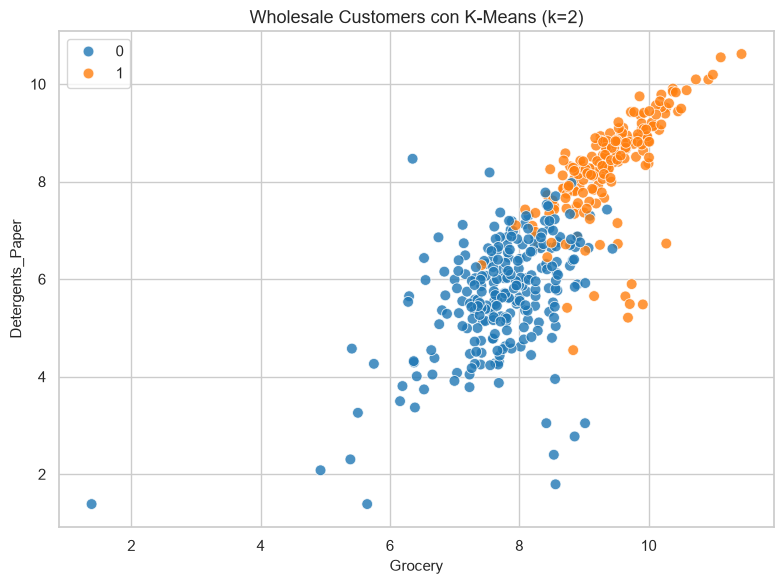

In [44]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=wholesale_log, x='Grocery', y='Detergents_Paper', hue=etiquetas_wholesale, palette='tab10', s=60, alpha=0.8, ax=ax)
ax.set_title(f'Wholesale Customers con K-Means (k={mejor_k_wholesale})')
plt.tight_layout()

### Conclusiones de Wholesale Customers

Wholesale Customers suele producir segmentos claros cuando se trabaja con una transformación logarítmica y estandarización previa. En este ejemplo, K-Means permite distinguir perfiles de compra con distinto peso en categorías como Grocery, Detergents_Paper y Fresh, y además deja ver cómo esos grupos se relacionan con `Channel` y `Region`.